### 1. colab 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_dataset_base = datasets.ImageFolder(root=train_dir, transform=train_transform_base)
train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=train_transform_aug)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader_base = DataLoader(train_dataset_base, batch_size=128, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Number of training samples: {len(train_dataset_base)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset_base.classes)}')
print(f'Class names: {train_dataset_base.classes}')
print(f'Example image shape: {train_dataset_base[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [3]:
import torch
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes: int = 100):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # 11x11 conv, stride 1
            nn.Conv2d(3, 64, kernel_size=11, stride=1, padding=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3 , stride=2),
            
            # 5x5 conv, padding 2
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # 3x3 conv
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # 3x3 conv
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # 3x3 conv
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [4]:
summary(AlexNet().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]          23,296
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 15, 15]               0
            Conv2d-4          [-1, 192, 15, 15]         307,392
              ReLU-5          [-1, 192, 15, 15]               0
         MaxPool2d-6            [-1, 192, 7, 7]               0
            Conv2d-7            [-1, 384, 7, 7]         663,936
              ReLU-8            [-1, 384, 7, 7]               0
            Conv2d-9            [-1, 256, 7, 7]         884,992
             ReLU-10            [-1, 256, 7, 7]               0
           Conv2d-11            [-1, 256, 7, 7]         590,080
             ReLU-12            [-1, 256, 7, 7]               0
        MaxPool2d-13            [-1, 256, 3, 3]               0
AdaptiveAvgPool2d-14            [-1, 25

### 4. train, test 함수 정의

In [5]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)

        loss = loss_fn(output_, target_)
        loss.backward()
        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [6]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [9]:
train_logs = { "baseline_acc":[], 
               "data_augmentation_acc":[],
            }
test_logs = { "baseline_acc":[],
              "data_augmentation_acc":[],
            }

models = {
    "data_augmentation_model": AlexNet().to(device),
    "baseline": AlexNet().to(device),
}

models_name = list(models.keys())

### 6. 학습

In [10]:
from tqdm.notebook import tqdm
EPOCHS = 50
criterion = nn.CrossEntropyLoss()

# batch_size별 모델 학습
test_logs_name = list(test_logs.keys())

# baseline 학습-----------------------------------------------------------------
current_model = models["baseline"]
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('baseline')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss = train(train_loader_base, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'baseline_train_acc:{train_acc:.4f} baseline_test_acc:{test_acc:.4f}')

    train_logs["baseline_acc"].append(train_acc)
    test_logs["baseline_acc"].append(test_acc)

baseline


  0%|          | 0/50 [00:00<?, ?it/s]

baseline_train_acc:0.0142 baseline_test_acc:0.0254
baseline_train_acc:0.2847 baseline_test_acc:0.3055
baseline_train_acc:0.4930 baseline_test_acc:0.4572
baseline_train_acc:0.6571 baseline_test_acc:0.5071
baseline_train_acc:0.8091 baseline_test_acc:0.5191
baseline_train_acc:0.9178 baseline_test_acc:0.5306
baseline_train_acc:0.9722 baseline_test_acc:0.5406
baseline_train_acc:0.9907 baseline_test_acc:0.5473
baseline_train_acc:0.9958 baseline_test_acc:0.5501
baseline_train_acc:0.9976 baseline_test_acc:0.5554
baseline_train_acc:0.9975 baseline_test_acc:0.5571


In [11]:
# data augmentation 학습--------------------------------------------------------------------
current_model = models["data_augmentation_model"]
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('data_augmentation')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss = train(train_loader_aug, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    if(epoch%5 == 0 or epoch == EPOCHS -1):
        print(f'data_augmentation_train_acc:{train_acc:.4f} data_augmentation_test_acc:{test_acc:.4f}')

    train_logs["data_augmentation_acc"].append(train_acc)
    test_logs["data_augmentation_acc"].append(test_acc)

data_augmentation


  0%|          | 0/50 [00:00<?, ?it/s]

data_augmentation_train_acc:0.0128 data_augmentation_test_acc:0.0235
data_augmentation_train_acc:0.2253 data_augmentation_test_acc:0.2706
data_augmentation_train_acc:0.3907 data_augmentation_test_acc:0.4016
data_augmentation_train_acc:0.5001 data_augmentation_test_acc:0.4797
data_augmentation_train_acc:0.5824 data_augmentation_test_acc:0.5254
data_augmentation_train_acc:0.6552 data_augmentation_test_acc:0.5563
data_augmentation_train_acc:0.7248 data_augmentation_test_acc:0.5710
data_augmentation_train_acc:0.7821 data_augmentation_test_acc:0.5814
data_augmentation_train_acc:0.8334 data_augmentation_test_acc:0.5906
data_augmentation_train_acc:0.8600 data_augmentation_test_acc:0.5931
data_augmentation_train_acc:0.8705 data_augmentation_test_acc:0.5943


### 7. 시각화

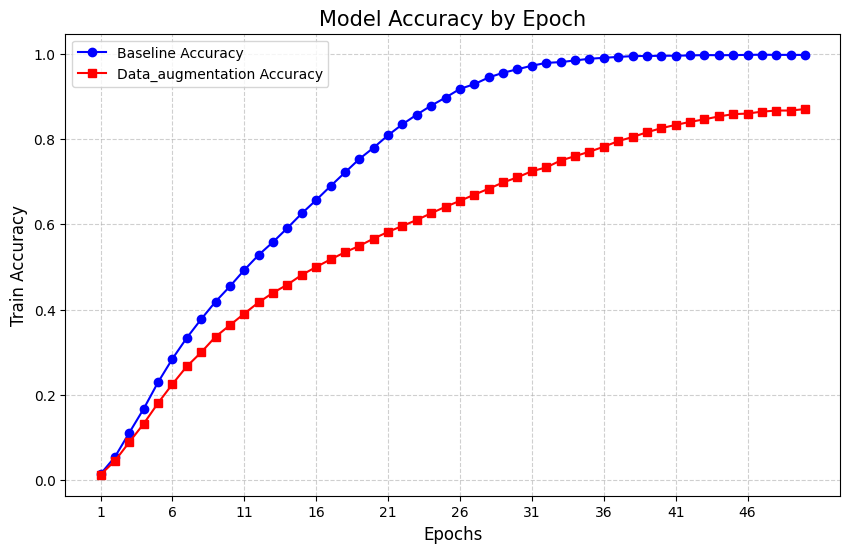

In [12]:
import matplotlib.pyplot as plt

# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, train_logs["baseline_acc"], 'b-o', label='Baseline Accuracy')
plt.plot(epochs, train_logs["data_augmentation_acc"], 'r-s', label='Data_augmentation Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

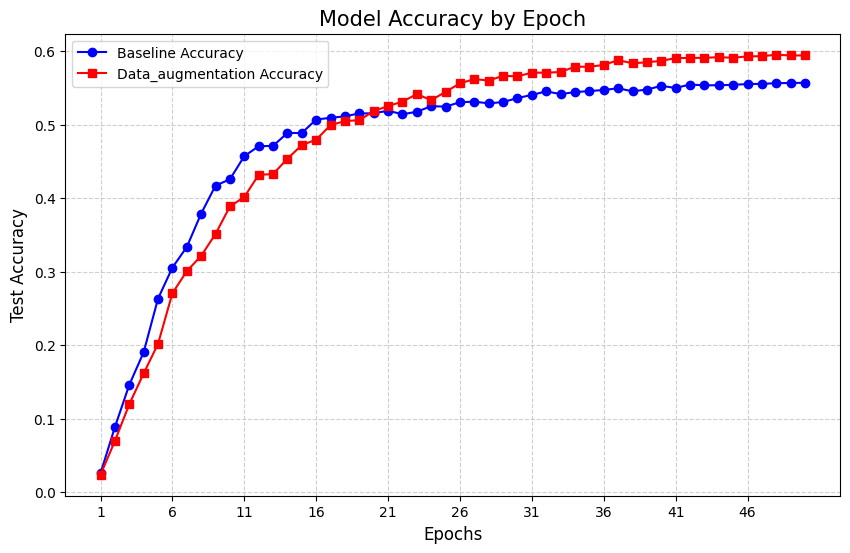

In [13]:
import matplotlib.pyplot as plt

# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, test_logs["baseline_acc"], 'b-o', label='Baseline Accuracy')
plt.plot(epochs, test_logs["data_augmentation_acc"], 'r-s', label='Data_augmentation Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()